In [1]:
# %% [markdown]
# # lab7: 학습되는 회로 — Ansatz (BasicEntanglerLayers)
# ### 양자 머신러닝 실습 (PennyLane · Colab)
#
# lab5에서 데이터를 인코딩했다면, 그 다음은 **ansatz** — 학습 파라미터를 가진 변분층이다.
# 인코딩(고정) 뒤에 ansatz(학습)를 얹고, 측정 결과로 만든 비용을 최소화하도록
# ansatz 파라미터를 조절한다. 이것이 변분 양자 회로(VQC)의 몸통이다.
#
# 여기서는 가장 단순한 ansatz인 **BasicEntanglerLayers**(큐빗당 회전 1개 + CNOT 링)만
# 사용한다. 구조가 단순해 첫 ansatz로 이해·학습이 쉽다.
#
# **학습 목표**
# 1. ansatz = 학습 파라미터를 가진 반복 층. BasicEntanglerLayers 구조 이해.
# 2. 층 수에 따라 파라미터가 (층 × 큐빗)으로 늘어남을 확인.
# 3. 여러 파라미터를 동시에 최적화해 목표 상태로 수렴시킨다.
# 4. 인코딩 + ansatz 를 합쳐 작은 변분 분류기를 학습시킨다.
#
# (그림 라벨은 영어, 코드 주석/출력은 한글)

# %%
# 설치 — Colab에서 최초 1회만: 아래 줄의 주석을 해제해 실행
!pip install -q pennylane


In [2]:

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SEED = 1234
rng = std_np.random.default_rng(SEED)



lab7-1: ansatz 구조 — BasicEntanglerLayers
  층수 L=1, 큐빗 3  ->  파라미터 shape (1, 3)  =  3 개
  층수 L=2, 큐빗 3  ->  파라미터 shape (2, 3)  =  6 개
  층수 L=3, 큐빗 3  ->  파라미터 shape (3, 3)  =  9 개

[BasicEntanglerLayers 회로 (2층, 3큐빗)]
0: ──RX(0.98)─╭●────╭X──RX(0.26)─╭●────╭X─┤  <Z>
1: ──RX(0.38)─╰X─╭●─│───RX(0.32)─╰X─╭●─│──┤     
2: ──RX(0.92)────╰X─╰●──RX(0.12)────╰X─╰●─┤     


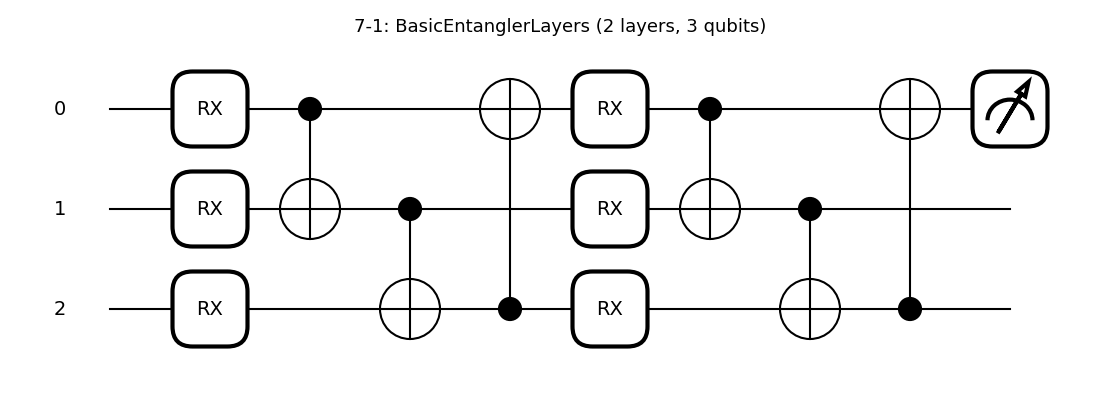

=> 층마다 '큐빗당 회전 + 이웃 CNOT 링' 이 반복된다. 회전각이 학습 파라미터.


In [3]:

# %%
# ===========================================================
#  7-1: BasicEntanglerLayers 구조와 파라미터 수
# ===========================================================
print("=" * 60)
print("lab7-1: ansatz 구조 — BasicEntanglerLayers")
print("=" * 60)

n = 3
dev = qml.device("default.qubit", wires=n)


@qml.qnode(dev)
def ansatz_demo(weights):
    qml.BasicEntanglerLayers(weights, wires=range(n))   # 큐빗당 RX + CNOT 링, 층 반복
    return qml.expval(qml.PauliZ(0))


# 층 수에 따른 파라미터 수 = (층 × 큐빗)
for L in [1, 2, 3]:
    shp = qml.BasicEntanglerLayers.shape(n_layers=L, n_wires=n)
    print(f"  층수 L={L}, 큐빗 {n}  ->  파라미터 shape {shp}  =  {int(std_np.prod(shp))} 개")

L = 2
shape = qml.BasicEntanglerLayers.shape(n_layers=L, n_wires=n)
demo_w = np.array(rng.random(shape))
print("\n[BasicEntanglerLayers 회로 (2층, 3큐빗)]")
print(qml.draw(ansatz_demo, level="device")(demo_w))
fig, ax = qml.draw_mpl(ansatz_demo, level="device",
                       style="black_white")(demo_w)
fig.suptitle("7-1: BasicEntanglerLayers (2 layers, 3 qubits)", fontsize=13)
plt.tight_layout()
plt.show()
print("=> 층마다 '큐빗당 회전 + 이웃 CNOT 링' 이 반복된다. 회전각이 학습 파라미터.")



In [4]:

# %%
# ===========================================================
#  7-2: ansatz 학습 — 여러 파라미터를 동시에 최적화
# ===========================================================
print("\n" + "=" * 60)
print("lab7-2: 여러 파라미터를 최적화해 목표로 수렴")
print("=" * 60)


@qml.qnode(dev)
def all_z(weights):
    qml.BasicEntanglerLayers(weights, wires=range(n))
    return [qml.expval(qml.PauliZ(i)) for i in range(n)]


def cost(weights):
    return np.sum(all_z(weights))       # 최소 = -n  (모든 큐빗이 |1>)


weights = np.array(0.1 * rng.random(shape), requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.3)

history = [float(cost(weights))]
for step in range(60):
    weights = opt.step(cost, weights)
    history.append(float(cost(weights)))

print(f"  파라미터 {int(std_np.prod(shape))}개  |  초기 cost={history[0]:+.3f}  ->  최종 cost={history[-1]:+.3f}  (목표 {-n})")
print("  => 경사하강이 모든 회전각을 동시에 조절해 비용을 최소값으로 끌어내렸다.")



lab7-2: 여러 파라미터를 최적화해 목표로 수렴
  파라미터 6개  |  초기 cost=+2.983  ->  최종 cost=-3.000  (목표 -3)
  => 경사하강이 모든 회전각을 동시에 조절해 비용을 최소값으로 끌어내렸다.


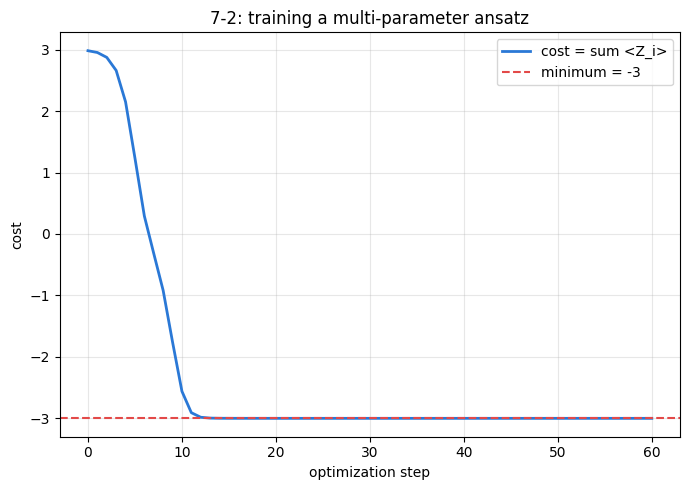

In [5]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history, "-", color="#2a78d6", lw=2, label="cost = sum <Z_i>")
ax.axhline(-n, color="#e34948", ls="--", lw=1.5, label=f"minimum = {-n}")
ax.set_xlabel("optimization step")
ax.set_ylabel("cost")
ax.set_title("7-2: training a multi-parameter ansatz")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [6]:

# %%
# ===========================================================
#  7-3: 인코딩 + ansatz = 변분 분류기
# ===========================================================
print("\n" + "=" * 60)
print("lab7-3: 인코딩 + BasicEntangler ansatz 로 분류 학습")
print("=" * 60)

# 2D 장난감 데이터: 두 클러스터 (선형 분리 가능)
c0 = rng.normal([-0.7, -0.7], 0.22, (20, 2))
c1 = rng.normal([0.7, 0.7], 0.22, (20, 2))
X = np.array(std_np.clip(std_np.vstack([c0, c1]), -1, 1), requires_grad=False)
Y = np.array([-1.0] * 20 + [1.0] * 20, requires_grad=False)   # 라벨 -1 / +1

dev2 = qml.device("default.qubit", wires=2)
LC = 3
shape_c = qml.BasicEntanglerLayers.shape(n_layers=LC, n_wires=2)



lab7-3: 인코딩 + BasicEntangler ansatz 로 분류 학습


In [7]:


@qml.qnode(dev2)
def classifier(x, weights):
    # 1) 인코딩: 특징 2개를 RY 로 (lab5 방식, [-1,1] -> [0,pi])
    qml.RY(np.pi * (x[0] + 1) / 2, wires=0)
    qml.RY(np.pi * (x[1] + 1) / 2, wires=1)
    # 2) ansatz: 학습되는 BasicEntanglerLayers
    qml.BasicEntanglerLayers(weights, wires=[0, 1])
    return qml.expval(qml.PauliZ(0))       # 예측 점수 (부호 -> 클래스)


def loss(weights, bias):
    preds = np.array([classifier(x, weights) + bias for x in X])
    return np.mean((preds - Y) ** 2)


def accuracy(weights, bias):
    preds = std_np.array([1 if float(classifier(x, weights) + bias) > 0 else -1 for x in X])
    return float(std_np.mean(preds == std_np.array(Y)))


In [8]:


weights = np.array(0.1 * rng.random(shape_c), requires_grad=True)
bias = np.array(0.0, requires_grad=True)
opt = qml.NesterovMomentumOptimizer(0.3)


In [9]:

loss_hist, acc_hist = [float(loss(weights, bias))], [accuracy(weights, bias)]
print(f"  학습 전: loss={loss_hist[0]:.3f}, accuracy={acc_hist[0]:.2f}")
for it in range(30):
    (weights, bias), l = opt.step_and_cost(loss, weights, bias)
    loss_hist.append(float(l))
    acc_hist.append(accuracy(weights, bias))
print(f"  학습 후: loss={loss_hist[-1]:.3f}, accuracy={acc_hist[-1]:.2f}")
print(f"  파라미터 {int(std_np.prod(shape_c))}개 + bias 1개로 두 클래스를 분리했다.")


  학습 전: loss=3.466, accuracy=0.00
  학습 후: loss=0.038, accuracy=1.00
  파라미터 6개 + bias 1개로 두 클래스를 분리했다.


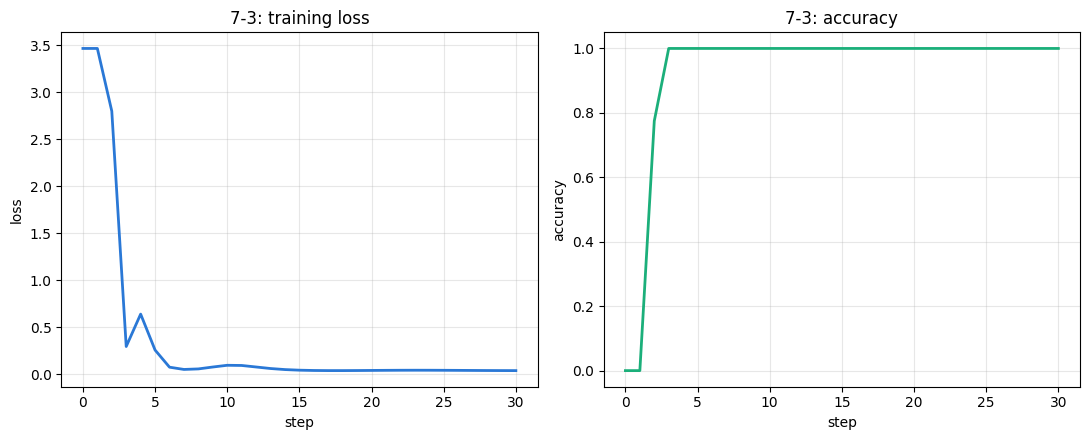

In [10]:

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4.5))
a.plot(loss_hist, "-", color="#2a78d6", lw=2)
a.set_xlabel("step"); a.set_ylabel("loss"); a.set_title("7-3: training loss"); a.grid(alpha=0.3)
b.plot(acc_hist, "-", color="#1baf7a", lw=2)
b.set_ylim(-0.05, 1.05)
b.set_xlabel("step"); b.set_ylabel("accuracy"); b.set_title("7-3: accuracy"); b.grid(alpha=0.3)
plt.tight_layout()
plt.show()


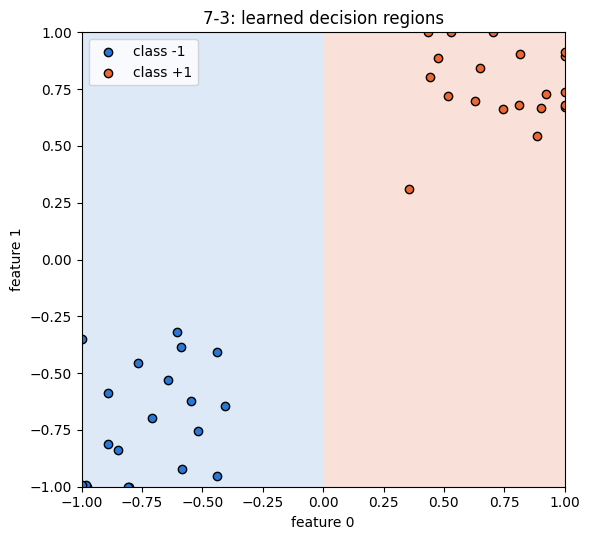


핵심: 인코딩(고정) + ansatz(학습) + 측정 + 최적화 = 변분 양자 분류기.
      더 표현력 있는 ansatz(StronglyEntangling 등)로 바꾸면 더 복잡한 경계도 학습 가능.


In [11]:

# 데이터와 학습된 결정 영역
fig, ax = plt.subplots(figsize=(6, 5.5))
gx, gy = std_np.meshgrid(std_np.linspace(-1, 1, 40), std_np.linspace(-1, 1, 40))
grid = std_np.c_[gx.ravel(), gy.ravel()]
zz = std_np.array([float(classifier(np.array(g), weights) + bias) for g in grid]).reshape(gx.shape)
ax.contourf(gx, gy, zz, levels=[-9, 0, 9], colors=["#cfe0f5", "#f7d5c9"], alpha=0.7)
ax.scatter(X[:20, 0], X[:20, 1], c="#2a78d6", label="class -1", edgecolor="k")
ax.scatter(X[20:, 0], X[20:, 1], c="#eb6834", label="class +1", edgecolor="k")
ax.set_xlabel("feature 0"); ax.set_ylabel("feature 1")
ax.set_title("7-3: learned decision regions")
ax.legend()
plt.tight_layout()
plt.show()

print("\n핵심: 인코딩(고정) + ansatz(학습) + 측정 + 최적화 = 변분 양자 분류기.")
print("      더 표현력 있는 ansatz(StronglyEntangling 등)로 바꾸면 더 복잡한 경계도 학습 가능.")